# Visualise seismic section with segy2netcdf format changing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import segyio
import os

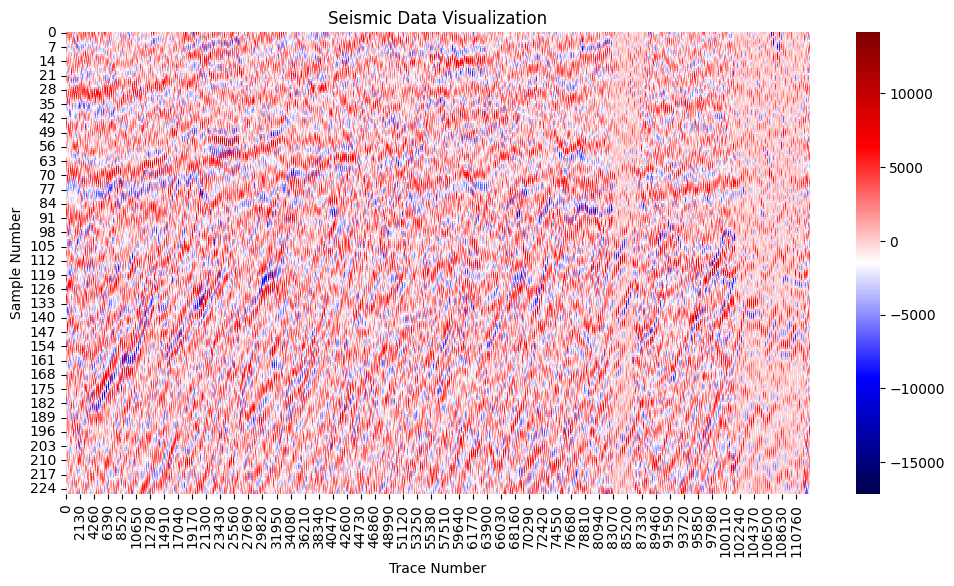

In [4]:
# Seismic data file path
seismic_file = '/home/ashraf/Downloads/ST8511r92.segy'
# Check if the file exists
if not os.path.exists(seismic_file):
    print(f"File not found: {seismic_file}")
else:
    # Read seismic data using segyio
    with segyio.open(seismic_file, "r",ignore_geometry=True) as segyfile:
        # Get the number of traces and samples
        num_traces = segyfile.tracecount
        num_samples = segyfile.samples.size
        
        # Initialize an array to hold seismic data
        seismic_data = np.zeros((num_traces, num_samples))
        
        # Read seismic traces into the array
        for i in range(num_traces):
            seismic_data[i, :] = segyfile.trace[i]
        
        # Plotting the seismic data
        plt.figure(figsize=(12, 6))
        sns.heatmap(seismic_data.T, cmap='seismic', cbar=True)
        plt.title('Seismic Data Visualization')
        plt.xlabel('Trace Number')
        plt.ylabel('Sample Number')
        plt.show()

In [5]:
with segyio.open(seismic_file, "r",ignore_geometry=True) as segyfile:
    # Get the number of traces and samples
    num_traces = segyfile.tracecount
    num_samples = segyfile.samples.size
    
    # Initialize an array to hold seismic data
    seismic_data = np.zeros((num_traces, num_samples))
    
    # Read seismic traces into the array
    for i in range(num_traces):
        seismic_data[i, :] = segyfile.trace[i]
    

In [9]:
with segyio.open(seismic_file, "r", ignore_geometry=True) as f:
    print(segyio.tracefield.keys)

{'TRACE_SEQUENCE_LINE': 1, 'TRACE_SEQUENCE_FILE': 5, 'FieldRecord': 9, 'TraceNumber': 13, 'EnergySourcePoint': 17, 'CDP': 21, 'CDP_TRACE': 25, 'TraceIdentificationCode': 29, 'NSummedTraces': 31, 'NStackedTraces': 33, 'DataUse': 35, 'offset': 37, 'ReceiverGroupElevation': 41, 'SourceSurfaceElevation': 45, 'SourceDepth': 49, 'ReceiverDatumElevation': 53, 'SourceDatumElevation': 57, 'SourceWaterDepth': 61, 'GroupWaterDepth': 65, 'ElevationScalar': 69, 'SourceGroupScalar': 71, 'SourceX': 73, 'SourceY': 77, 'GroupX': 81, 'GroupY': 85, 'CoordinateUnits': 89, 'WeatheringVelocity': 91, 'SubWeatheringVelocity': 93, 'SourceUpholeTime': 95, 'GroupUpholeTime': 97, 'SourceStaticCorrection': 99, 'GroupStaticCorrection': 101, 'TotalStaticApplied': 103, 'LagTimeA': 105, 'LagTimeB': 107, 'DelayRecordingTime': 109, 'MuteTimeStart': 111, 'MuteTimeEND': 113, 'TRACE_SAMPLE_COUNT': 115, 'TRACE_SAMPLE_INTERVAL': 117, 'GainType': 119, 'InstrumentGainConstant': 121, 'InstrumentInitialGain': 123, 'Correlated': 

In [18]:
with segyio.open(seismic_file, "r", ignore_geometry=True) as f:

    data = segyio.tools.cube(f)  # works even without geometry
    print(data.shape)

TypeError: object of type 'NoneType' has no len()

In [17]:
import numpy as np

with segyio.open(seismic_file, "r", ignore_geometry=True) as f:
    traces = np.array([trace for trace in f.trace])
    print(traces.shape)
    print(traces)
    print(traces[0])
    

(112875, 227)
[[-1595.6051   -4630.4575   -5701.582    ...    11.081434   189.60216
   -345.96002 ]
 [-1238.5636   -1774.1259   -1060.043    ... -2309.688    -2131.1672
  -1238.5636  ]
 [-1595.6051   -4630.4575   -5701.582    ...    11.081434   189.60216
   -345.96002 ]
 ...
 [-1595.6051   -4630.4575   -5701.582    ...    11.081434   189.60216
   -345.96002 ]
 [-1238.5636   -1774.1259   -1060.043    ... -2309.688    -2131.1672
  -1238.5636  ]
 [-1595.6051   -4630.4575   -5701.582    ...    11.081434   189.60216
   -345.96002 ]]
[-1595.6051   -4630.4575   -5701.582    -4094.8953    -703.00146
  2688.8923    3938.5374    3402.9753    2153.33      1439.2472
   903.68506    189.60216   -703.00146  -1417.0844   -1774.1259
 -1595.6051    -524.4808     546.6436    1082.2058     725.16437
   189.60216     11.081434   189.60216    725.16437   1260.7266
  1617.768     1974.8094    1796.2887     546.6436   -1774.1259
 -4273.416    -5166.0195   -3737.8538    -167.43929   3224.4546
  4295.579     2

In [ ]:
import numpy as np
import plotly.graph_objects as go
import segyio


class SegyLoader:

    def __init__(self, filepath):
        self.filepath = filepath
        self.data = None

    def load_data(self):

        print("Loading SEGY file...")

        with segyio.open(self.filepath, ignore_geometry=True) as f:

            traces = np.array([np.copy(t) for t in f.trace])

            n_traces, n_samples = traces.shape

            # approximate grid
            n_inline = int(np.sqrt(n_traces))
            n_crossline = n_traces // n_inline

            traces = traces[:n_inline * n_crossline]

            self.data = traces.reshape(n_inline, n_crossline, n_samples)

        print("Loaded cube shape:", self.data.shape)


class SeisLab3DViewer:

    def __init__(self, loader):

        if loader.data is None:
            raise ValueError("Seismic data not loaded")

        self.data = loader.data

    def plot_3d(self, inline_idx=None, xline_idx=None, clip=98, downsample=2):

        data = self.data

        if downsample > 1:
            data = data[::downsample, ::downsample, ::downsample]

        ni, nx, nt = data.shape

        if inline_idx is None:
            inline_idx = ni // 2

        if xline_idx is None:
            xline_idx = nx // 2

        vmin, vmax = np.percentile(data, [100 - clip, clip])

        fig = go.Figure()

        # Inline slice
        inline = data[inline_idx, :, :].T

        X, Z = np.meshgrid(np.arange(nx), np.arange(nt))
        Y = np.full_like(X, inline_idx)

        fig.add_surface(
            x=X,
            y=Y,
            z=Z,
            surfacecolor=inline,
            colorscale="RdBu_r",
            cmin=vmin,
            cmax=vmax,
            showscale=True
        )

        # Crossline slice
        cross = data[:, xline_idx, :].T

        Y, Z = np.meshgrid(np.arange(ni), np.arange(nt))
        X = np.full_like(Y, xline_idx)

        fig.add_surface(
            x=X,
            y=Y,
            z=Z,
            surfacecolor=cross,
            colorscale="RdBu_r",
            cmin=vmin,
            cmax=vmax,
            showscale=False
        )

        fig.update_layout(

            title="SeisLab 3D Seismic Viewer",

            scene=dict(
                xaxis_title="Crossline",
                yaxis_title="Inline",
                zaxis_title="Time",
                zaxis=dict(autorange="reversed"),
                aspectratio=dict(x=1, y=1, z=1.5)
            ),

            width=1200,
            height=800
        )

        fig.show()


# ----------------------------------
# MAIN PROGRAM
# ----------------------------------

if __name__ == "__main__":

    filepath = "/home/ashraf/Downloads/ST8511r92.segy"

    loader = SegyLoader(filepath)

    loader.load_data()

    viewer = SeisLab3DViewer(loader)

    viewer.plot_3d()